# XGBoost:

### Importando as bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 2. Carregamento dos Artefatos e dos Dados

 Diferente do primeiro notebook, agora nosso primeiro passo é carregar os artefatos que já criamos.
 Isso garante que todos os modelos sejam treinados e avaliados sob as mesmas condições exatas.

 - `label_encoder.joblib`: Garante que a classe 'BENIGN' seja sempre '0', 'DDoS' seja sempre '2', etc.
 - `features_realistas.joblib`: Garante que usaremos exatamente o mesmo subconjunto de 14 features.

 Depois, carregamos e limpamos os dados brutos da mesma forma que antes.

In [2]:
# --- 1. Carrega os artefatos salvos ---

# Define o caminho absoluto para a pasta 'models'
try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')

# Carrega o codificador de rótulos e a lista de features
try:
    label_encoder = joblib.load(os.path.join(model_dir, 'label_encoder.joblib'))
    features_realistas = joblib.load(os.path.join(model_dir, 'features_realistas.joblib'))
    print("Artefatos (LabelEncoder e lista de features) carregados com sucesso.")
    print(f"Número de features a serem usadas: {len(features_realistas)}")
except FileNotFoundError:
    raise RuntimeError("ERRO: Artefatos do Notebook 01 não encontrados. Por favor, execute o notebook 01-RandomForest primeiro.")

# --- 2. Carrega e limpa os dados (mesmo processo do notebook 01) ---

caminho_dados = os.path.join(project_root, 'MachineLearningCSV', 'MachineLearningCVE')
todos_os_arquivos = glob.glob(os.path.join(caminho_dados, "*.csv"))

lista_de_dfs = []
for arquivo in todos_os_arquivos:
    df = pd.read_csv(arquivo, low_memory=False)
    lista_de_dfs.append(df)

dados = pd.concat(lista_de_dfs, axis=0, ignore_index=True)

# Limpeza
dados.columns = dados.columns.str.strip()
for col in dados.columns:
    if dados[col].dtype == 'object' and col != 'Label':
        dados[col] = pd.to_numeric(dados[col], errors='coerce')
dados.replace([np.inf, -np.inf], np.nan, inplace=True)
dados.dropna(inplace=True)

# Separação e codificação
X_bruto = dados.drop('Label', axis=1)
y_bruto = dados['Label']

# Usa o LabelEncoder JÁ CARREGADO para transformar os rótulos
y_codificado = label_encoder.transform(y_bruto)

# Seleciona apenas as features realistas do DataFrame recém carregado
X_realista = X_bruto[features_realistas]

print("\nDataset carregado e processado com sucesso.")
print(f"Shape do DataFrame de features (X_realista): {X_realista.shape}")


Artefatos (LabelEncoder e lista de features) carregados com sucesso.
Número de features a serem usadas: 14

Dataset carregado e processado com sucesso.
Shape do DataFrame de features (X_realista): (2827876, 14)


### 3. Divisão dos Dados em Treino e Teste

 Esta etapa é idêntica à do notebook anterior, garantindo que o XGBoost seja treinado e
 testado exatamente nos mesmos "pedaços" de dados que o Random Forest.

 A utilização do mesmo `random_state=42` e da mesma estratégia de estratificação (`stratify`)
 é o que garante essa consistência, tornando a comparação entre os modelos justa.

In [3]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_realista,
    y_codificado,
    test_size=0.3,
    random_state=42,
    stratify=y_codificado
)

print("Divisão dos dados concluída.")
print(f"Shape do conjunto de treino (X_treino): {X_treino.shape}")
print(f"Shape do conjunto de teste (X_teste):   {X_teste.shape}")

Divisão dos dados concluída.
Shape do conjunto de treino (X_treino): (1979513, 14)
Shape do conjunto de teste (X_teste):   (848363, 14)


### 4. Otimização com GridSearchCV e Validação Cruzada

Seguindo a mesma metodologia do Random Forest, aplicamos o `GridSearchCV` para encontrar a combinação de hiperparâmetros que otimiza a performance do XGBoost. O foco é validar a arquitetura do modelo e buscar um equilíbrio ideal entre precisão, recall e eficiência computacional.

In [5]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

print("--- Iniciando GridSearchCV para o XGBClassifier ---")
print("AVISO: Este processo será demorado e usará o conjunto de treino COMPLETO.")

# 1. Define a grade de parâmetros para o XGBoost
param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [5, 7],
    'learning_rate': [0.1, 0.2]
}

# 2. Instancia o GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_grid=param_grid_xgb,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='f1_weighted'
)

# 3. Executa a busca no CONJUNTO DE TREINO COMPLETO
# Este passo levará várias horas.
grid_search_xgb.fit(X_treino, y_treino)

# 4. Mostra os melhores parâmetros encontrados
print("\n--- GridSearchCV Concluído ---")
print("Melhores parâmetros encontrados para XGBoost:")
print(grid_search_xgb.best_params_)

# Armazena os melhores parâmetros para usar na próxima etapa
best_xgb_params = grid_search_xgb.best_params_

--- Iniciando GridSearchCV para o XGBClassifier ---
AVISO: Este processo será demorado e usará o conjunto de treino COMPLETO.
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=100; total time= 5.8min
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=100; total time= 5.9min
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=100; total time= 5.9min
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=100; total time= 6.1min
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=100; total time= 6.1min
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time= 8.6min
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time= 8.6min
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time= 8.6min
[CV] END ...learning_rate=0.2, max_depth=5, n_estimators=100; total time= 4.1min
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=100; total time= 5.9min
[CV]

### 4. Treinamento do Modelo XGBoost

 O XGBoost (eXtreme Gradient Boosting) é um algoritmo de "boosting", que funciona de forma sequencial:
 ele cria uma árvore, vê onde ela errou, e a próxima árvore que ele cria foca especificamente em corrigir esses erros.

 Parâmetros importantes:
 - `objective='multi:softmax'`: Informa ao XGBoost que este é um problema de classificação com múltiplas classes.
 - `num_class`: Precisamos dizer a ele quantas classes distintas existem.
 - `n_estimators=100`: O número de árvores a serem criadas sequencialmente.
 - `use_label_encoder=False`: Uma configuração para evitar um aviso (deprecation warning) nas versões mais recentes.
 - `eval_metric='mlogloss'`: Métrica de avaliação usada internamente pelo modelo.

In [6]:
print("--- Treinando o Modelo XGBoost Final com os Parâmetros Otimizados ---")

# Instancia o modelo com os MELHORES parâmetros encontrados
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    **best_xgb_params  # <-- Desempacota o dicionário de parâmetros otimizados
)

# Treina o modelo final no conjunto de treino COMPLETO
xgb_model.fit(X_treino, y_treino)

print("\n--- Treinamento do modelo final concluído ---")

--- Treinando o Modelo XGBoost Final com os Parâmetros Otimizados ---

--- Treinamento do modelo final concluído ---


### 5. Avaliação do Modelo

 Assim como no notebook anterior, vamos avaliar a performance do XGBoost no conjunto de teste.
 As métricas são as mesmas, o que nos permite uma comparação direta entre a performance do XGBoost e a do Random Forest.

 Vamos analisar o Relatório de Classificação, a Matriz de Confusão (Absoluta e Normalizada) e a Curva ROC.

--- Relatório de Classificação (XGBoost) ---
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.98      0.99    681396
                       Bot       0.95      0.71      0.81       587
                      DDoS       0.93      1.00      0.96     38408
             DoS GoldenEye       0.89      0.30      0.45      3088
                  DoS Hulk       0.95      1.00      0.97     69037
          DoS Slowhttptest       0.66      0.73      0.69      1650
             DoS slowloris       0.76      0.55      0.64      1739
               FTP-Patator       0.87      1.00      0.93      2380
                Heartbleed       0.50      0.33      0.40         3
              Infiltration       0.00      0.00      0.00        11
                  PortScan       0.83      0.99      0.90     47641
               SSH-Patator       1.00      0.99      0.99      1769
  Web Attack � Brute Force       0.71      0.07      0.12       452
We

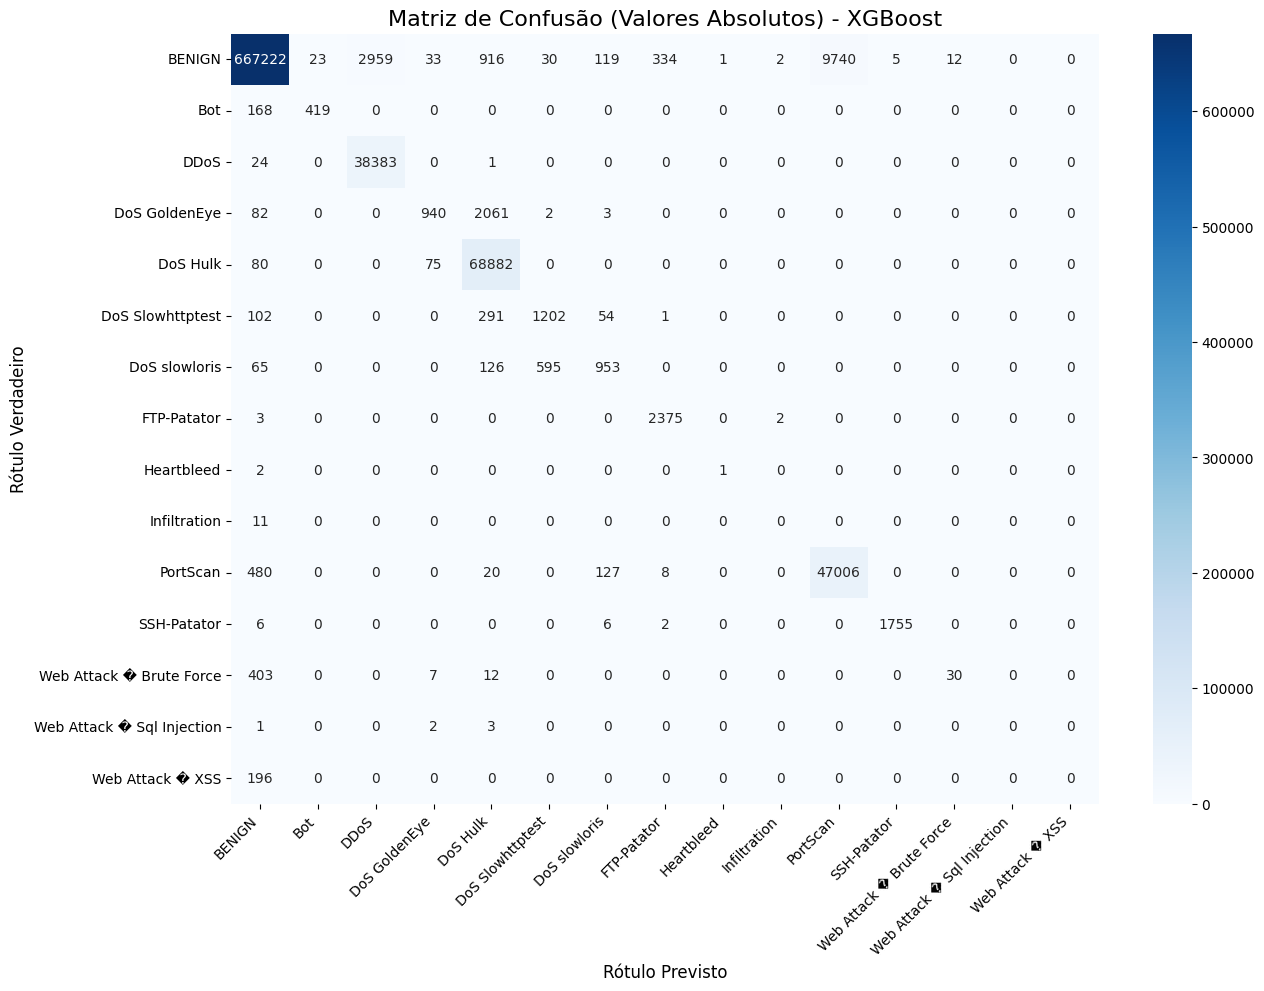

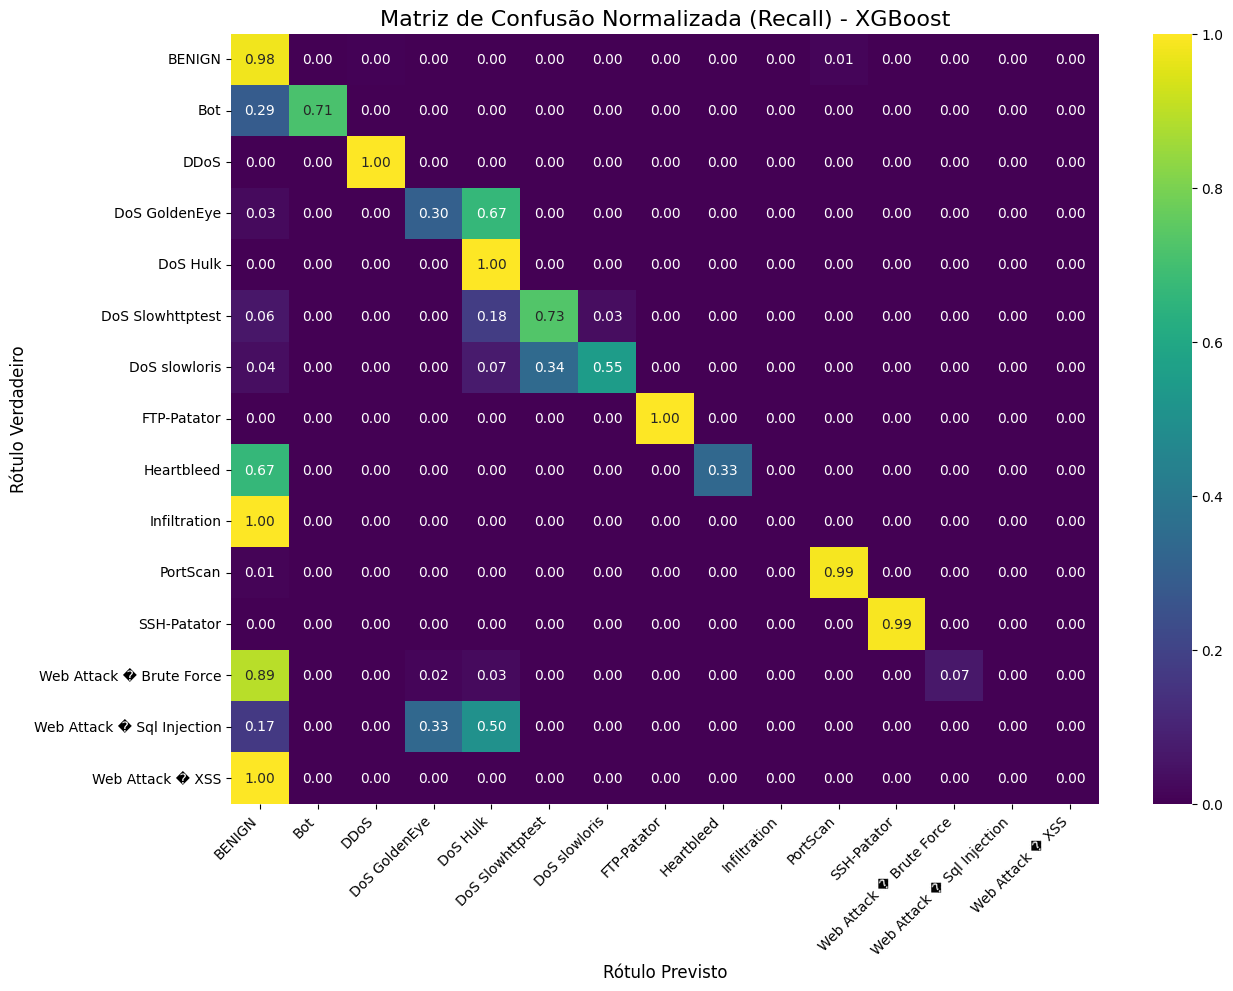

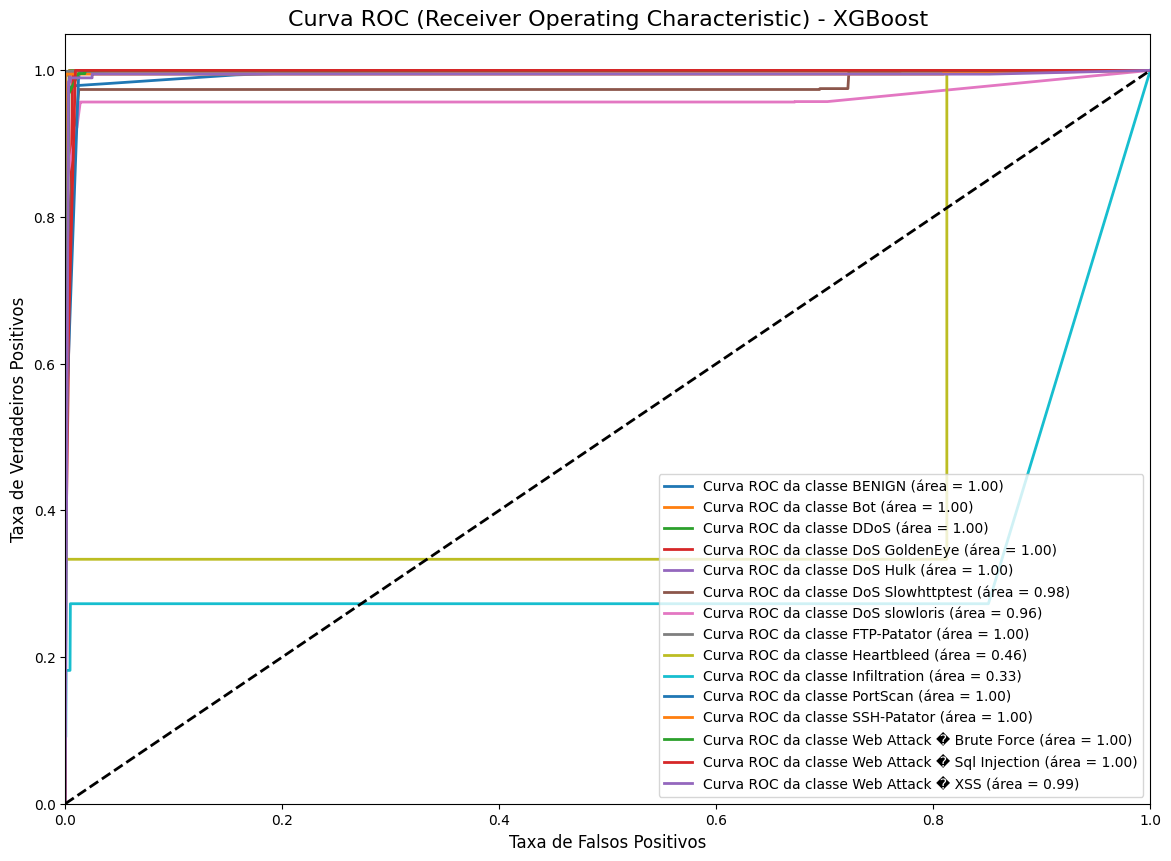

In [7]:
# O modelo já foi treinado. Agora, usamos o conjunto de teste para fazer previsões.
y_pred = xgb_model.predict(X_teste)
y_pred_proba = xgb_model.predict_proba(X_teste)

# --- Relatório de Classificação ---
print("--- Relatório de Classificação (XGBoost) ---")
print(classification_report(y_teste, y_pred, target_names=label_encoder.classes_.astype(str)))

# --- F1-Score Ponderado ---
f1 = f1_score(y_teste, y_pred, average='weighted')
print(f"\nF1-Score (Ponderado): {f1:.4f}")

# --- Matriz de Confusão (Absoluta) ---
cm_abs = confusion_matrix(y_teste, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm_abs, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_.astype(str),
            yticklabels=label_encoder.classes_.astype(str))
plt.title('Matriz de Confusão (Valores Absolutos) - XGBoost', fontsize=16)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# --- Matriz de Confusão (Normalizada/Recall) ---
cm_norm = cm_abs.astype('float') / cm_abs.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(14, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=label_encoder.classes_.astype(str),
            yticklabels=label_encoder.classes_.astype(str))
plt.title('Matriz de Confusão Normalizada (Recall) - XGBoost', fontsize=16)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# --- Curva ROC (Um-contra-o-Resto) ---
from sklearn.preprocessing import label_binarize
y_teste_bin = label_binarize(y_teste, classes=np.arange(len(label_encoder.classes_)))
n_classes = y_teste_bin.shape[1]
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_teste_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(14, 10))
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Curva ROC da classe {class_name} (área = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
plt.title('Curva ROC (Receiver Operating Characteristic) - XGBoost', fontsize=16)
plt.legend(loc="lower right")
plt.show()

### 6. Salvando o Modelo XGBoost

 Etapa final: salvamos o modelo treinado em disco.

 É importante notar que **não precisamos salvar o LabelEncoder ou a lista de features novamente**, pois eles são os mesmos do

In [8]:
# --- Define o diretório de salvamento (mesma lógica anterior) ---
try:
    # Tenta o caminho a partir da pasta /notebooks
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    # Fallback se já estiver na raiz
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')

# Garante que o diretório existe
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Diretório criado: {model_dir}")

# --- Salva o modelo XGBoost treinado ---
model_path = os.path.join(model_dir, 'xgboost_model.joblib')
joblib.dump(xgb_model, model_path)
print(f"Modelo XGBoost salvo em: {model_path}")

# --- Verificação Final ---
print("\n--- Verificando arquivos salvos no diretório 'models' ---")
try:
    # Lista os arquivos para confirmar que o novo modelo está lá
    print(sorted(os.listdir(model_dir)))
except Exception as e:
    print(f"Não foi possível listar os arquivos: {e}")

Modelo XGBoost salvo em: /home/henrique/PycharmProjects/ndr-tcc/models/xgboost_model.joblib

--- Verificando arquivos salvos no diretório 'models' ---
['catboost_model.joblib', 'ensemble_model.joblib', 'features_realistas.joblib', 'isolation_forest_model.joblib', 'label_encoder.joblib', 'mlp_model.joblib', 'random_forest_model.joblib', 'top_15_features.joblib', 'xgboost_model.joblib']
